In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from src.TFT import StockTFT

# --- Global Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path("../")
DATA_PATH = PROJECT_ROOT / "data" / "processed_data" / "technical_ER_dataset.pt"

# Select the best run from your training results
RUN_ID = "technical_ER_dataset_20260127_1910"
MODEL_DIR = PROJECT_ROOT / "results" / "training" / RUN_ID
CHECKPOINT_PATH = MODEL_DIR / "best_model.pt"

SPY_PATH = PROJECT_ROOT / "data/raw_data/technical_data/SPY_RAW.csv"
INITIAL_BALANCE = 10000.0

print(f"📡 Simulation Engine Initialized | Device: {DEVICE}")

📡 Simulation Engine Initialized | Device: cpu


In [38]:
all_samples = torch.load(DATA_PATH, weights_only=False)
num_samples = len(all_samples)
test_start = int(num_samples * 0.85)
test_samples = all_samples[test_start:] # This is our isolated test partition

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
config = checkpoint['config']

# 3. Reconstruct Model from src using saved history for input_dim
model = StockTFT(
    input_dim=checkpoint['history']['feat_imp'][0].shape[0],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    n_heads=config.get('n_heads', 8)
).to(DEVICE)

model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f"✅ Loaded {len(test_samples)} test samples directly from .pt file.")
print(f"✅ Model {RUN_ID} reassembled and ready for inference.")

✅ Loaded 60 test samples directly from .pt file.
✅ Model technical_ER_dataset_20260127_1910 reassembled and ready for inference.


🚀 Simulation: 2025-11-11 to 2025-12-23


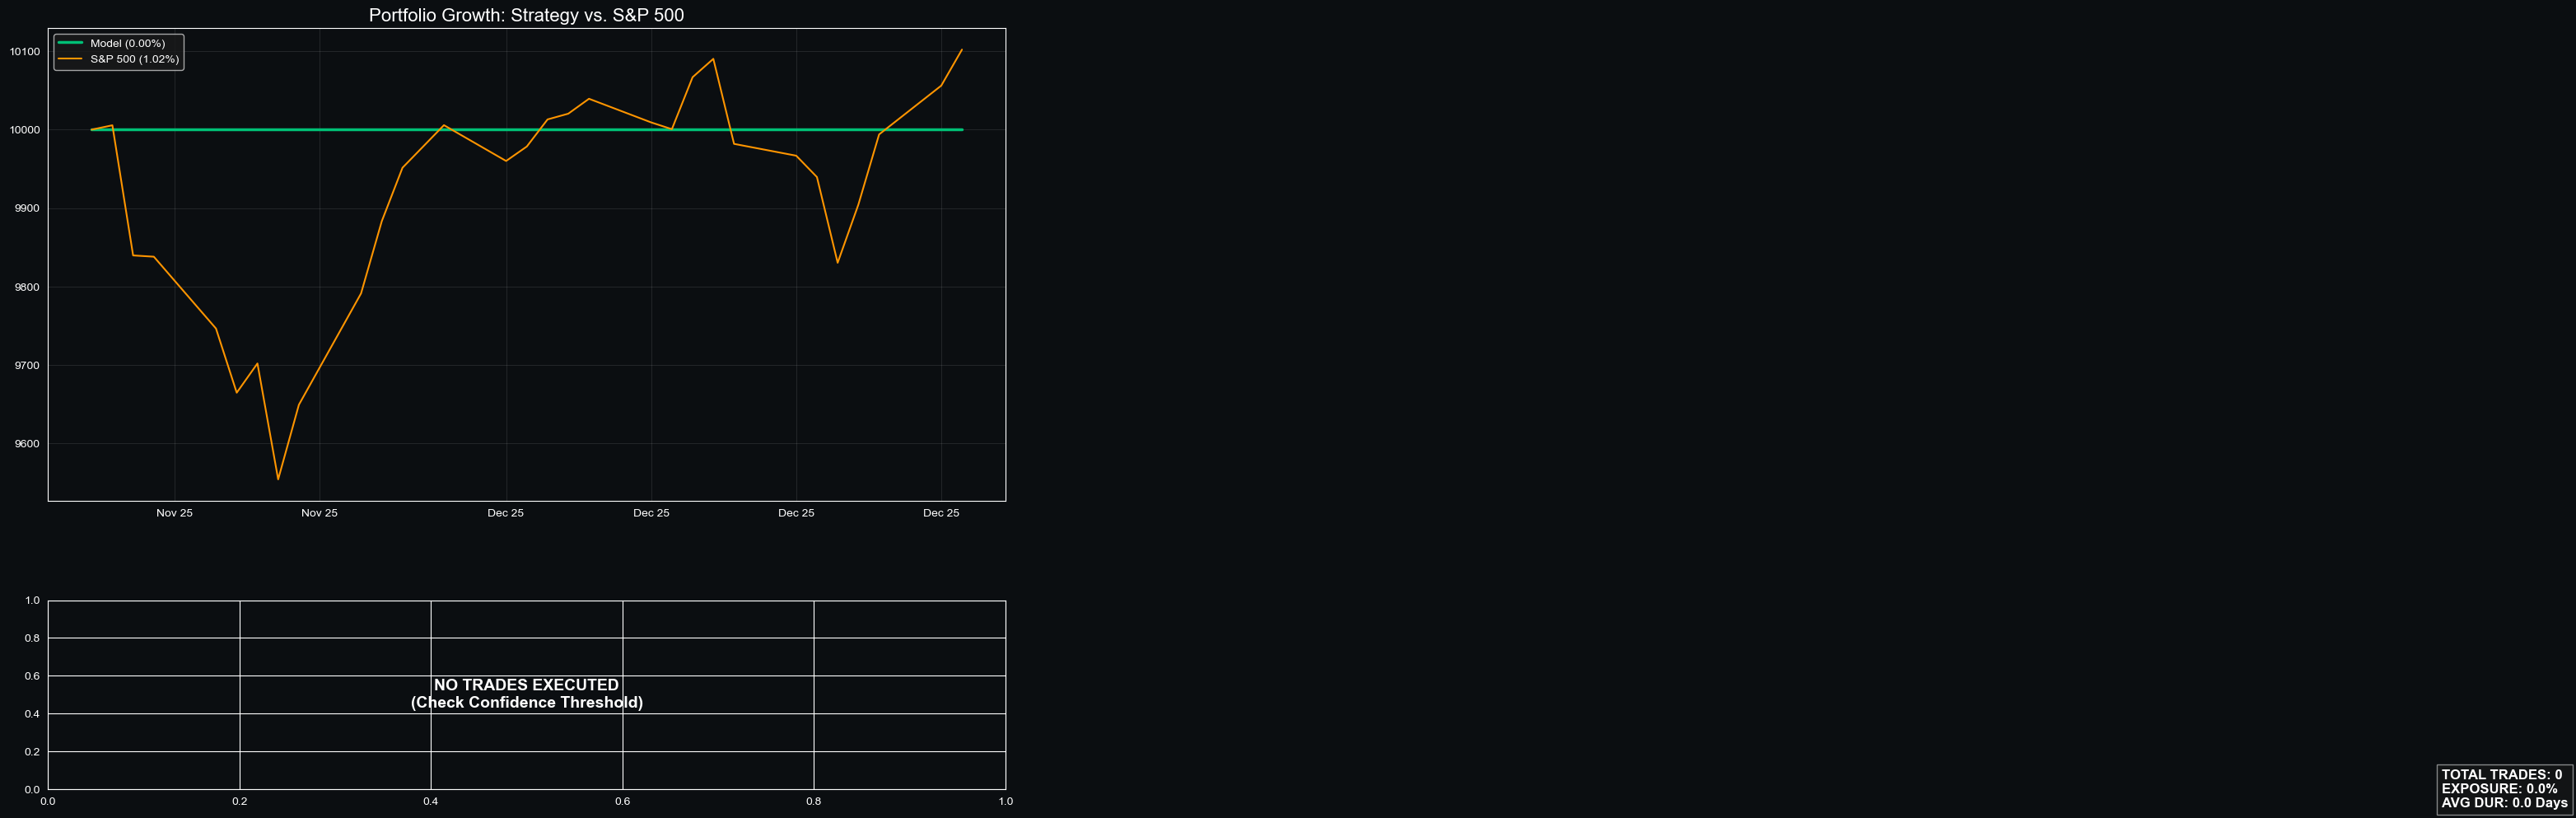

In [40]:
RAW_TECH_DIR = PROJECT_ROOT / "data" / "raw_data" / "technical_data"

# Load S&P 500
df_spy = pd.read_csv(SPY_PATH)
df_spy['Date'] = pd.to_datetime(df_spy['Date'])
spy_lookup = df_spy.set_index('Date')['Close'].to_dict()

# Group test samples by date for sequential processing
samples_by_date = {}
for s in test_samples:
    d = pd.to_datetime(s['metadata']['date'])
    if d not in samples_by_date: samples_by_date[d] = []
    samples_by_date[d].append(s)

sorted_test_dates = sorted(samples_by_date.keys())
spy_start_price = spy_lookup.get(sorted_test_dates[0], list(spy_lookup.values())[0])

balance = INITIAL_BALANCE
balance_history, balance_dates = [], []
wins, losses, neutrals = 0, 0, 0
total_trades, total_trade_days = 0, 0
transaction_lines = [] # (date, color, balance)

print(f"🚀 Simulation: {sorted_test_dates[0].date()} to {sorted_test_dates[-1].date()}")
i = 0
while i < len(sorted_test_dates):
    curr_date = sorted_test_dates[i]
    day_candidates = samples_by_date[curr_date]

    # A. Inference: Find top confidence prediction for the day
    best_trade = None
    max_conf = -1.0

    for s in day_candidates:
        x = torch.tensor(s['x'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        sid = torch.tensor([s['static_id']]).to(DEVICE)
        with torch.no_grad():
            out = model(x, sid)
            probs = torch.softmax(out, dim=1)[0]
            pred = out.argmax(1).item()
            conf = probs[pred].item()

            if pred == 2 and conf > 0.50: # Only Buy signals > 50%
                if conf > max_conf:
                    max_conf, best_trade = conf, (s, pred)

    # B. Execution Logic
    if best_trade:
        s_data, p_id = best_trade
        ticker = s_data['metadata']['ticker']
        total_trades += 1

        # Load raw ticker data for ATR and forward-testing
        df_stock = pd.read_csv(RAW_TECH_DIR / f"{ticker}_RAW.csv")
        df_stock['Date'] = pd.to_datetime(df_stock['Date'])
        stock_idx = df_stock[df_stock['Date'] == curr_date].index[0]

        # Entry setup
        entry_bal = balance
        open_t1 = df_stock.iloc[stock_idx + 1]['Open']

        # Approximate ATR from High/Low features in sample or raw file
        tr = np.max([df_stock.iloc[stock_idx]['High'] - df_stock.iloc[stock_idx]['Low'],
                    abs(df_stock.iloc[stock_idx]['High'] - df_stock.iloc[stock_idx-1]['Close']),
                    abs(df_stock.iloc[stock_idx]['Low'] - df_stock.iloc[stock_idx-1]['Close'])])
        atr_pct = 1.5 * (tr / open_t1)
        target_p, stop_p = open_t1 * (1 + atr_pct), open_t1 * (1 - atr_pct)

        # Walk forward 5 days
        resolved, duration = False, 0
        for k in range(1, 6):
            if stock_idx + k >= len(df_stock): break
            day_data = df_stock.iloc[stock_idx + k]
            if day_data['High'] >= target_p:
                balance *= (1.0 + atr_pct); wins += 1; resolved = True; color = '#00C076'; duration = k; break
            elif day_data['Low'] <= stop_p:
                balance *= (1.0 - atr_pct); losses += 1; resolved = True; color = '#FF4D4D'; duration = k; break

        if not resolved:
            net_ret = (df_stock.iloc[stock_idx + 5]['Close'] / open_t1) - 1
            balance *= (1.0 + net_ret); neutrals += 1; color = 'grey'; duration = 5

        total_trade_days += duration
        transaction_lines.append((curr_date, color, entry_bal))

        for d_off in range(duration + 1):
            if i + d_off < len(sorted_test_dates):
                balance_history.append(balance)
                balance_dates.append(sorted_test_dates[i + d_off])
        i += (duration + 1)
    else:
        balance_history.append(balance); balance_dates.append(curr_date)
        i += 1

import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# Check if we have data to plot to avoid NaN errors
if len(balance_dates) > 0:
    spy_hist = [INITIAL_BALANCE * (spy_lookup.get(d, spy_start_price)/spy_start_price) for d in balance_dates]
    final_roi = ((balance/INITIAL_BALANCE)-1)*100
    spy_roi = ((spy_hist[-1]/INITIAL_BALANCE)-1)*100
else:
    balance_dates, balance_history, spy_hist = [pd.to_datetime(sorted_test_dates[0])], [INITIAL_BALANCE], [INITIAL_BALANCE]
    final_roi, spy_roi = 0, 0

fig = plt.figure(figsize=(15, 12), facecolor='#0B0E11')
gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.3)

# 4A. Equity Curve Plot
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#0B0E11')
ax1.plot(balance_dates, balance_history, color='#00C076', lw=2.5, label=f'Model ({final_roi:.2f}%)')
ax1.plot(balance_dates, spy_hist, color='#FF9500', lw=1.5, label=f'S&P 500 ({spy_roi:.2f}%)')

for date, color, y_entry in transaction_lines:
    ax1.vlines(x=date, ymin=y_entry, ymax=max(balance_history)*1.05, color=color, ls='--', lw=0.8, alpha=0.6)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax1.tick_params(colors='white')
ax1.grid(alpha=0.1)
ax1.legend(facecolor='#1A1A1A', labelcolor='white', loc='upper left')
ax1.set_title("Portfolio Growth: Strategy vs. S&P 500", color='white', fontsize=16)

# 4B. Pie Chart Dashboard (Fixed with Safety Check)
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#0B0E11')

if total_trades > 0:
    labels, sizes, colors = ['Wins', 'Neutrals', 'Losses'], [wins, neutrals, losses], ['#00C076', 'grey', '#FF4D4D']
    l_f, s_f, c_f = zip(*[(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0])

    ax2.pie(s_f, labels=l_f, autopct='%1.1f%%', startangle=140, colors=c_f,
            pctdistance=0.8, textprops={'color': "white", 'weight':'bold'})
    ax2.add_artist(plt.Circle((0,0), 0.65, fc='#0B0E11')) # Donut hole
else:
    ax2.text(0.5, 0.5, "NO TRADES EXECUTED\n(Check Confidence Threshold)",
             ha='center', va='center', color='white', fontsize=14, fontweight='bold')

# Stats box
exposure = (total_trade_days/len(balance_dates))*100 if len(balance_dates) > 0 else 0
avg_dur = (total_trade_days/total_trades) if total_trades > 0 else 0
stats_text = f"TOTAL TRADES: {total_trades}\nEXPOSURE: {exposure:.1f}%\nAVG DUR: {avg_dur:.1f} Days"

ax2.text(2.5, 0, stats_text, ha='left', va='center', color='white', fontsize=12, fontweight='bold',
         bbox=dict(facecolor='#1A1A1A', alpha=0.5, edgecolor='white'))

plt.show()